<a href="https://colab.research.google.com/github/sin-siminn/CVPR-MID/blob/main/CNN_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import zipfile


zip_path = '/content/drive/Othercomputers/My Laptop/dataset/A Dataset of Multi-View Preclinical Tooth Preparat.zip'
extract_path = '/content/dataset'


with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzipped")

Unzipped


In [4]:
import zipfile
import os

# Inner zip file path
inner_zip_path = '/content/dataset/A Dataset of Multi-View Preclinical Tooth Preparat/Separate View Images.zip'
final_extract_path = '/content/dataset/extracted_images'

# Unzipping actual image collection
print("Extracting images from inner zip...")
with zipfile.ZipFile(inner_zip_path, 'r') as zip_ref:
    zip_ref.extractall(final_extract_path)

print("Images Unzipped")

# Check extracted structure
print("\nFoldes inside extracted_images:")
print(os.listdir(final_extract_path))

Extracting images from inner zip...
Images Unzipped

Foldes inside extracted_images:
['Separate View Images']


In [5]:
import os
import shutil
import random

source_dir = '/content/dataset/extracted_images/Separate View Images'
base_dir = '/content/dataset/structured_dataset'

classes = ['Canines', 'Incisors', 'Molars', 'PreMolars']
split_ratio = 0.8

# Create Train & Val directories
for split in ['train', 'val']:
    for cls in classes:
        os.makedirs(os.path.join(base_dir, split, cls), exist_ok=True)

# Distribute images physically
for cls in classes:
    src_cls_path = os.path.join(source_dir, cls)
    images = os.listdir(src_cls_path)
    random.shuffle(images)

    train_count = int(len(images) * split_ratio)
    train_images = images[:train_count]
    val_images = images[train_count:]

    # Copy to train folder
    for img in train_images:
        shutil.copy(os.path.join(src_cls_path, img), os.path.join(base_dir, 'train', cls, img))

    # Copy to val folder
    for img in val_images:
        shutil.copy(os.path.join(src_cls_path, img), os.path.join(base_dir, 'val', cls, img))

print("✅ Physical Folder Structure Created Successfully!")
print("Paths: /content/dataset/structured_dataset/train & val")

✅ Physical Folder Structure Created Successfully!
Paths: /content/dataset/structured_dataset/train & val


In [6]:
import os

images_base_path = '/content/dataset/extracted_images/Separate View Images'

print("Contents inside 'Separate View Images':")
print(os.listdir(images_base_path))

Contents inside 'Separate View Images':
['Molars', 'Canines', 'PreMolars', 'Incisors']


In [7]:
import torch
import torchvision.transforms as transforms
from torchvision import datasets
from torch.utils.data import DataLoader

basic_transform = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

BATCH_SIZE = 32
train_path = '/content/dataset/structured_dataset/train'
val_path   = '/content/dataset/structured_dataset/val'

train_dataset = datasets.ImageFolder(train_path, transform=basic_transform)
val_dataset   = datasets.ImageFolder(val_path, transform=basic_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("✅ Success! Physical Dataset Loaders Ready.")
print("Classes detected:", train_dataset.classes)
print("Total train images:", len(train_dataset))
print("Total val images  :", len(val_dataset))

✅ Success! Physical Dataset Loaders Ready.
Classes detected: ['Canines', 'Incisors', 'Molars', 'PreMolars']
Total train images: 3077
Total val images  : 772


In [8]:
import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class ToothClassifier(nn.Module):
    def __init__(self, use_dropout=True):
        super(ToothClassifier, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 18 * 18, 256),
            nn.ReLU(),
            nn.Dropout(0.5) if use_dropout else nn.Identity(),
            nn.Linear(256, 4)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

print("✅ Flexible Model Class Ready!")

✅ Flexible Model Class Ready!


In [9]:
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=5):
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(epochs):
        model.train()
        running_loss, correct_train, total_train = 0.0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total_train += labels.size(0)
            correct_train += predicted.eq(labels).sum().item()

        train_acc = 100. * correct_train / total_train

        # Validation phase
        model.eval()
        val_loss, correct_val, total_val = 0.0, 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = outputs.max(1)
                total_val += labels.size(0)
                correct_val += predicted.eq(labels).sum().item()

        val_acc = 100. * correct_val / total_val

        train_losses.append(running_loss/len(train_loader))
        val_losses.append(val_loss/len(val_loader))
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        print(f"Epoch [{epoch+1}/{epochs}] | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

    return train_losses, val_losses, train_accs, val_accs

In [10]:
import torchvision.transforms as transforms
from torchvision import datasets
from torch.utils.data import DataLoader

# Basic Transform (Round 1 er jonno)
basic_transform = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

BATCH_SIZE = 32
train_path = '/content/dataset/structured_dataset/train'
val_path   = '/content/dataset/structured_dataset/val'

# Train & Val Dataset Setup
train_dataset = datasets.ImageFolder(train_path, transform=basic_transform)
val_dataset   = datasets.ImageFolder(val_path, transform=basic_transform)

# Data Loaders Definition
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("✅ DataLoaders standardly loaded successfully!")

✅ DataLoaders standardly loaded successfully!


In [11]:
print("--- 🔴 ROUND 1: Baseline Training (No Augmentation / No Dropout) ---")

model_r1 = ToothClassifier(use_dropout=False).to(device)
criterion = nn.CrossEntropyLoss()
optimizer_r1 = optim.Adam(model_r1.parameters(), lr=0.001)

r1_t_loss, r1_v_loss, r1_t_acc, r1_v_acc = train_model(
    model_r1, train_loader, val_loader, criterion, optimizer_r1, epochs=5
)

--- 🔴 ROUND 1: Baseline Training (No Augmentation / No Dropout) ---
Epoch [1/5] | Train Acc: 70.00% | Val Acc: 89.38%
Epoch [2/5] | Train Acc: 88.63% | Val Acc: 89.38%
Epoch [3/5] | Train Acc: 90.80% | Val Acc: 92.88%
Epoch [4/5] | Train Acc: 92.20% | Val Acc: 93.26%
Epoch [5/5] | Train Acc: 94.35% | Val Acc: 93.01%


In [12]:
import torchvision.transforms as transforms
from torchvision import datasets
from torch.utils.data import DataLoader

print("\n--- 🟢 ROUND 2: Advanced Training (With Augmentation & Dropout) ---")

# Data Augmentation Setup
aug_transform = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.RandomRotation(15),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset_aug = datasets.ImageFolder(train_path, transform=aug_transform)
train_loader_aug = DataLoader(train_dataset_aug, batch_size=BATCH_SIZE, shuffle=True)

# Model Training with Dropout
model_r2 = ToothClassifier(use_dropout=True).to(device)
optimizer_r2 = optim.Adam(model_r2.parameters(), lr=0.001)

r2_t_loss, r2_v_loss, r2_t_acc, r2_v_acc = train_model(
    model_r2, train_loader_aug, val_loader, criterion, optimizer_r2, epochs=5
)

# Final Saved Model
torch.save(model_r2.state_dict(), 'tooth_classifier_model.pth')
print("✅ Round 2 Model saved successfully!")


--- 🟢 ROUND 2: Advanced Training (With Augmentation & Dropout) ---
Epoch [1/5] | Train Acc: 48.20% | Val Acc: 69.82%
Epoch [2/5] | Train Acc: 62.37% | Val Acc: 74.22%
Epoch [3/5] | Train Acc: 68.22% | Val Acc: 74.74%
Epoch [4/5] | Train Acc: 70.46% | Val Acc: 84.97%
Epoch [5/5] | Train Acc: 73.25% | Val Acc: 83.81%
✅ Round 2 Model saved successfully!


In [13]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


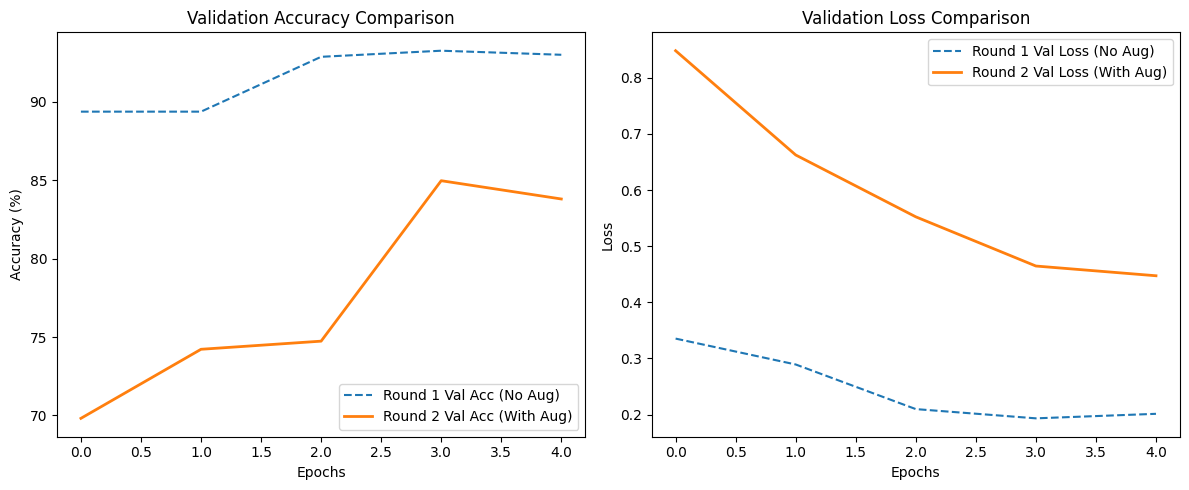

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(r1_v_acc, label='Round 1 Val Acc (No Aug)', linestyle='--')
plt.plot(r2_v_acc, label='Round 2 Val Acc (With Aug)', linewidth=2)
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(r1_v_loss, label='Round 1 Val Loss (No Aug)', linestyle='--')
plt.plot(r2_v_loss, label='Round 2 Val Loss (With Aug)', linewidth=2)
plt.title('Validation Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

Classification Report:
              precision    recall  f1-score   support

     Canines       0.82      0.79      0.81       121
    Incisors       1.00      0.04      0.08        23
      Molars       0.95      0.97      0.96       320
   PreMolars       0.91      0.97      0.94       308

    accuracy                           0.91       772
   macro avg       0.92      0.69      0.70       772
weighted avg       0.92      0.91      0.90       772



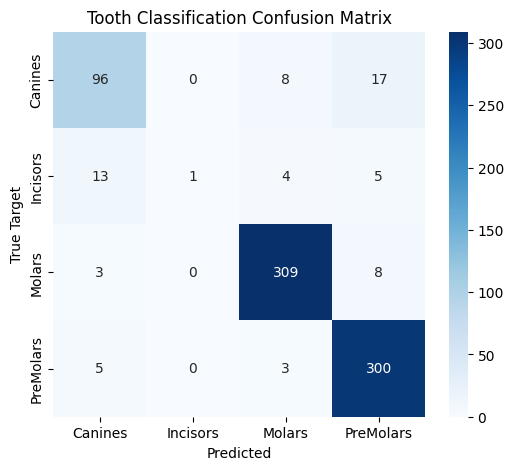

In [14]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Print Classification Report (Precision, Recall, F1-score)
print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=train_dataset.classes))

# Plot Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=train_dataset.classes,
            yticklabels=train_dataset.classes)
plt.xlabel('Predicted')
plt.ylabel('True Target')
plt.title('Tooth Classification Confusion Matrix')
plt.show()

In [15]:
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total Trainable Parameters: {total_params:,}")

Total Trainable Parameters: 10,711,812


In [19]:
len(train_dataset)


3077

In [20]:
len(val_dataset)

772